### Hospital Readmission Class ML Note book

### Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import classification_report, confusion_matrix

### Read Data

In [133]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

### EDA `Train Data Frame`

In [134]:
df_train.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,197920182,110382426,Caucasian,Female,[80-90),?,3,1,7,5,...,No,No,No,No,No,No,No,Ch,Yes,>30
1,30870324,1276911,Caucasian,Male,[70-80),?,3,5,1,3,...,No,No,No,No,No,No,No,No,Yes,NO
2,126616944,92115693,Caucasian,Female,[70-80),?,3,3,1,8,...,No,Up,No,No,No,No,No,Ch,Yes,NO
3,303646118,32010471,Caucasian,Male,[50-60),?,6,1,7,7,...,No,No,No,No,No,No,No,No,No,>30
4,109444026,2402271,Caucasian,Male,[40-50),?,1,1,6,2,...,No,Steady,No,No,No,No,No,No,Yes,NO


### Priniting info()

In [135]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71236 entries, 0 to 71235
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              71236 non-null  int64 
 1   patient_nbr               71236 non-null  int64 
 2   race                      71236 non-null  object
 3   gender                    71236 non-null  object
 4   age                       71236 non-null  object
 5   weight                    71236 non-null  object
 6   admission_type_id         71236 non-null  int64 
 7   discharge_disposition_id  71236 non-null  int64 
 8   admission_source_id       71236 non-null  int64 
 9   time_in_hospital          71236 non-null  int64 
 10  payer_code                71236 non-null  object
 11  medical_specialty         71236 non-null  object
 12  num_lab_procedures        71236 non-null  int64 
 13  num_procedures            71236 non-null  int64 
 14  num_medications       

### Dropping Idintifiers column

In [136]:
# df_train.drop('encounter_id', axis=1, inplace=True)
# df_train.drop('patient_nbr', axis=1, inplace=True)

### Show Data

In [137]:
df_train

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,197920182,110382426,Caucasian,Female,[80-90),?,3,1,7,5,...,No,No,No,No,No,No,No,Ch,Yes,>30
1,30870324,1276911,Caucasian,Male,[70-80),?,3,5,1,3,...,No,No,No,No,No,No,No,No,Yes,NO
2,126616944,92115693,Caucasian,Female,[70-80),?,3,3,1,8,...,No,Up,No,No,No,No,No,Ch,Yes,NO
3,303646118,32010471,Caucasian,Male,[50-60),?,6,1,7,7,...,No,No,No,No,No,No,No,No,No,>30
4,109444026,2402271,Caucasian,Male,[40-50),?,1,1,6,2,...,No,Steady,No,No,No,No,No,No,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71231,242809818,39060180,Caucasian,Male,[40-50),?,1,2,7,1,...,No,Steady,No,No,No,No,No,No,Yes,>30
71232,406694150,43796898,Caucasian,Male,[70-80),?,3,1,1,2,...,No,No,No,No,No,No,No,No,No,NO
71233,83519910,15749334,Caucasian,Male,[60-70),?,1,1,7,3,...,No,Steady,No,No,No,No,No,No,Yes,<30
71234,227511798,67898304,Caucasian,Female,[60-70),?,1,1,7,1,...,No,No,No,No,No,No,No,No,No,NO


### From pervious Simple EDA I find That Data have high level of `incositenty` so Now, Trying to resolve this inconsistant Data

### Column `weight`

In [138]:
Question_marks_number = df_train[df_train["weight"]=="?"].shape[0]
print("Number of question marks in weight column:", Question_marks_number) 
print("Percentage of question marks in weight column:", (Question_marks_number / df_train.shape[0]) * 100, "%")

Number of question marks in weight column: 69027
Percentage of question marks in weight column: 96.89903981133135 %


### See unique weight labels

In [139]:
# see unique values in weight column
print("Unique values in weight column:", df_train["weight"].unique())

Unique values in weight column: ['?' '[100-125)' '[75-100)' '[50-75)' '[25-50)' '[150-175)' '[125-150)'
 '[175-200)' '[0-25)' '>200']


### Form pervious weight check we find that `weight` columns is ~ 97 --> `?` which have no mean so drob it

In [140]:
df_train.drop('weight', axis=1, inplace=True)

### Check `payer_code`

In [141]:
Question_marks_number_payer_code = df_train[df_train["payer_code"]=="?"].shape[0]
print("Number of question marks in payer_code column:", Question_marks_number_payer_code)
print("Percentage of question marks in payer_code column:", (Question_marks_number_payer_code / df_train.shape[0]) * 100, "%")

Number of question marks in payer_code column: 28218
Percentage of question marks in payer_code column: 39.61199393565052 %


#### `payer_code` has percentage of `?` ~40%

#### So we there is an need to replace `?` with some Value `mode value` due to this is catigoral column maybe ?

#### Draw Clasees number in bar plot

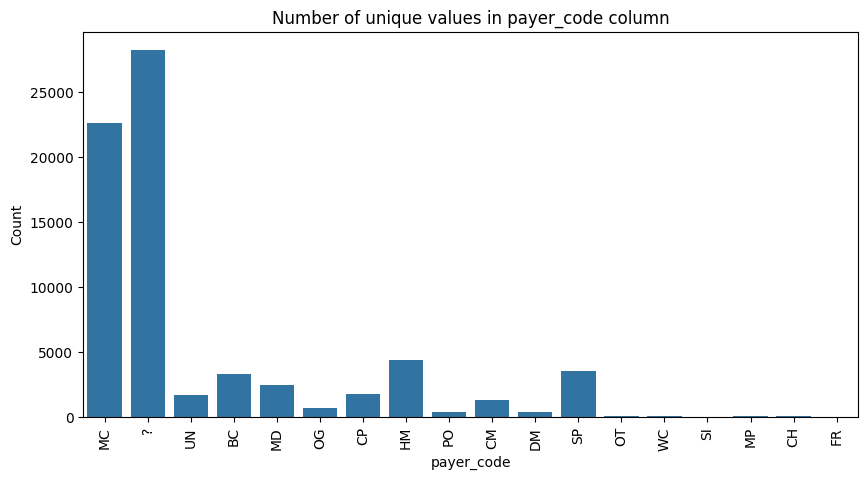

In [142]:
#show number of unique values in payer_code column bar plot
plt.figure(figsize=(10,5))
sns.countplot(x='payer_code', data=df_train)
plt.title('Number of unique values in payer_code column')
plt.xlabel('payer_code')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

#### rename it with `Unkmown` I think it's best choise 

In [143]:
df_train['payer_code'] = df_train['payer_code'].replace('?', 'Unknown')

### `medical_specialty` Column

#### Show Percentage of column

In [144]:
Question_marks_number_medical_specialty = df_train[df_train["medical_specialty"]=="?"].shape[0]
print("Number of question marks in medical_specialty column:", Question_marks_number_medical_specialty)
print("Percentage of question marks in medical_specialty column:", (Question_marks_number_medical_specialty / df_train.shape[0]) * 100, "%")

Number of question marks in medical_specialty column: 34987
Percentage of question marks in medical_specialty column: 49.114211915323715 %


### Drop `medical_sepciallity` column

In [145]:
#drop medical_specialty column
df_train.drop('medical_specialty', axis=1, inplace=True)

In [146]:
df_train

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,197920182,110382426,Caucasian,Female,[80-90),3,1,7,5,MC,...,No,No,No,No,No,No,No,Ch,Yes,>30
1,30870324,1276911,Caucasian,Male,[70-80),3,5,1,3,Unknown,...,No,No,No,No,No,No,No,No,Yes,NO
2,126616944,92115693,Caucasian,Female,[70-80),3,3,1,8,MC,...,No,Up,No,No,No,No,No,Ch,Yes,NO
3,303646118,32010471,Caucasian,Male,[50-60),6,1,7,7,Unknown,...,No,No,No,No,No,No,No,No,No,>30
4,109444026,2402271,Caucasian,Male,[40-50),1,1,6,2,UN,...,No,Steady,No,No,No,No,No,No,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71231,242809818,39060180,Caucasian,Male,[40-50),1,2,7,1,MD,...,No,Steady,No,No,No,No,No,No,Yes,>30
71232,406694150,43796898,Caucasian,Male,[70-80),3,1,1,2,MC,...,No,No,No,No,No,No,No,No,No,NO
71233,83519910,15749334,Caucasian,Male,[60-70),1,1,7,3,Unknown,...,No,Steady,No,No,No,No,No,No,Yes,<30
71234,227511798,67898304,Caucasian,Female,[60-70),1,1,7,1,MC,...,No,No,No,No,No,No,No,No,No,NO


#### Pre-Processing nulls

In [147]:
# Check for missing values
missing_values = df_train.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               67452
A1Cresult                   59392
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide       

### Try to discover null columns

In [148]:
#determine data types for max_glu_serum and A1Cresult columns
print("Data type of max_glu_serum column:", df_train['max_glu_serum'].dtype)
print("Data type of A1Cresult column:", df_train['A1Cresult'].dtype)

Data type of max_glu_serum column: object
Data type of A1Cresult column: object


In [149]:
#print unique values in max_glu_serum and A1Cresult columns
print("Unique values in max_glu_serum column:", df_train['max_glu_serum'].unique())
print("Unique values in A1Cresult column:", df_train['A1Cresult'].unique())

Unique values in max_glu_serum column: [nan '>200' 'Norm' '>300']
Unique values in A1Cresult column: ['>7' nan '>8' 'Norm']


In [150]:
#check percentage of each missing value in max_glu_serum and A1Cresult columns using isnull() and sum()
missing_values_max_glu_serum = df_train['max_glu_serum'].isnull().sum()
missing_values_A1Cresult = df_train['A1Cresult'].isnull().sum()
print("Number of missing values in max_glu_serum column:", missing_values_max_glu_serum)
print("Percentage of missing values in max_glu_serum column:", (missing_values_max_glu_serum / df_train.shape[0]) * 100, "%")
print("Number of missing values in A1Cresult column:", missing_values_A1Cresult)
print("Percentage of missing values in A1Cresult column:", (missing_values_A1Cresult / df_train.shape[0]) * 100, "%")

Number of missing values in max_glu_serum column: 67452
Percentage of missing values in max_glu_serum column: 94.68807906114885 %
Number of missing values in A1Cresult column: 59392
Percentage of missing values in A1Cresult column: 83.37357515862766 %


### Drop `max_glu_serum` `A1Cresult` drop sparse features

In [151]:
#drop max_glu_serum and A1Cresult columns
df_train.drop('max_glu_serum', axis=1, inplace=True)
df_train.drop('A1Cresult', axis=1, inplace=True)

#### `number_diagnoses` is numeirc column 

#### See Distrpution of `number_diagnoses` Column

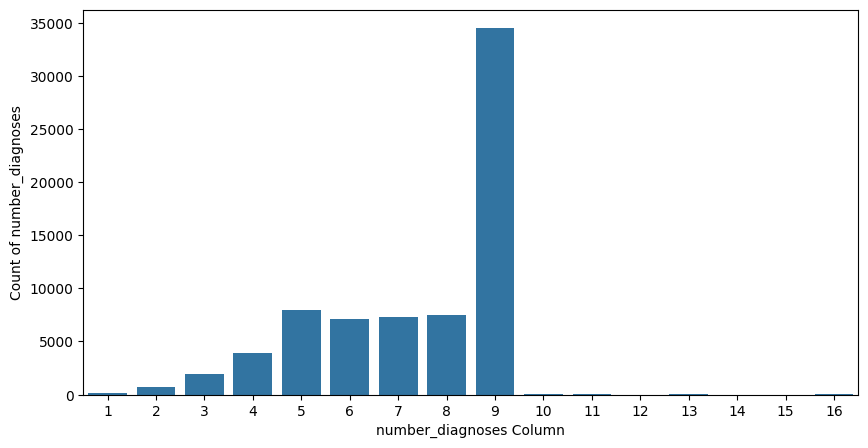

In [152]:
#see distribution of number_diagnoses column
plt.figure(figsize=(10,5))
sns.countplot(x="number_diagnoses",data=df_train)
plt.xlabel("number_diagnoses Column")
plt.ylabel("Count of number_diagnoses")
plt.xticks()
plt.show()

### Check Nulls

In [153]:
#check nulls at dataset
print("Number of null values in each column:\n", df_train.isnull().sum())

Number of null values in each column:
 encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
m

### Well Done let's start make Feature Enginering

In [154]:
#Check object columns
object_columns = df_train.select_dtypes(include=['object']).columns
print("Object columns in the dataset:\n", object_columns)

Object columns in the dataset:
 Index(['race', 'gender', 'age', 'payer_code', 'diag_1', 'diag_2', 'diag_3',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


In [155]:
#print unique values for each object column
for column in object_columns:
    print(f"Unique values in {column} column:", df_train[column].unique())

Unique values in race column: ['Caucasian' 'Other' 'AfricanAmerican' '?' 'Hispanic' 'Asian']
Unique values in gender column: ['Female' 'Male' 'Unknown/Invalid']
Unique values in age column: ['[80-90)' '[70-80)' '[50-60)' '[40-50)' '[60-70)' '[30-40)' '[90-100)'
 '[20-30)' '[10-20)' '[0-10)']
Unique values in payer_code column: ['MC' 'Unknown' 'UN' 'BC' 'MD' 'OG' 'CP' 'HM' 'PO' 'CM' 'DM' 'SP' 'OT'
 'WC' 'SI' 'MP' 'CH' 'FR']
Unique values in diag_1 column: ['682' '715' '157' '276' '564' '401' '599' 'V53' '428' '414' '493' '433'
 '404' '820' '415' '486' '996' '481' '491' '722' '250.12' '518' '730'
 '295' '238' '411' '786' '569' '578' '511' '250.8' '296' '560' '440' '424'
 '427' '250.7' '532' '435' '197' '453' '618' '997' '250.13' '787' '430'
 '707' '812' '434' '403' '584' '426' '348' '277' '571' '161' '531' '924'
 '998' '490' '861' '423' '562' '38' '530' '280' '351' '557' '648' '840'
 '410' '250.42' '250.1' '658' '780' '386' '733' '724' '420' '519' '566'
 '241' '162' '710' '402' '995' '25

### make train Test split before any preprocessing 

### I have been write script to make Proffesional Encoding to data

In [156]:
from encoding_Script import encode_features
df_encoded = encode_features(df_train)
df_encoded.dtypes  # all numeric

encounter_id          int64
patient_nbr           int64
gender                int64
age                   int64
admission_type_id     int64
                      ...  
payer_code_SI         int64
payer_code_SP         int64
payer_code_UN         int64
payer_code_Unknown    int64
payer_code_WC         int64
Length: 68, dtype: object

In [157]:
df_encoded.head()

,encounter_id,patient_nbr,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,payer_code_MD,payer_code_MP,payer_code_OG,payer_code_OT,payer_code_PO,payer_code_SI,payer_code_SP,payer_code_UN,payer_code_Unknown,payer_code_WC
0,197920182,110382426,0,8,3,1,7,5,40,2,...,0,0,0,0,0,0,0,0,0,0
1,30870324,1276911,1,7,3,5,1,3,22,1,...,0,0,0,0,0,0,0,0,1,0
2,126616944,92115693,0,7,3,3,1,8,33,5,...,0,0,0,0,0,0,0,0,0,0
3,303646118,32010471,1,5,6,1,7,7,52,1,...,0,0,0,0,0,0,0,0,1,0
4,109444026,2402271,1,4,1,1,6,2,47,2,...,0,0,0,0,0,0,0,1,0,0


### Make feature Enginerring steps

In [158]:
from Feature_Enginerring import engineer_features
df_final = engineer_features(df_encoded)  # 66 → 35 columns

In [159]:
df_final

,encounter_id,patient_nbr,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,insulin,glyburide-metformin,change,diabetesMed,readmitted,payer_type,race,total_prior_visits,total_medications_on,any_medication_change
0,197920182,110382426,0,8,3,1,7,5,40,2,...,0,0,0,1,1,4,0,0,2,0
1,30870324,1276911,1,7,3,5,1,3,22,1,...,0,0,1,1,0,0,0,0,1,0
2,126616944,92115693,0,7,3,3,1,8,33,5,...,3,0,0,1,0,4,0,0,1,1
3,303646118,32010471,1,5,6,1,7,7,52,1,...,0,0,1,0,1,0,0,4,0,0
4,109444026,2402271,1,4,1,1,6,2,47,2,...,1,0,1,1,0,2,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71231,242809818,39060180,1,4,1,2,7,1,34,0,...,1,0,1,1,1,4,0,1,1,0
71232,406694150,43796898,1,7,3,1,1,2,26,0,...,0,0,1,0,0,4,0,6,0,0
71233,83519910,15749334,1,6,1,1,7,3,44,1,...,1,0,1,1,2,0,0,4,1,0
71234,227511798,67898304,0,6,1,1,7,1,12,0,...,0,0,1,0,0,4,0,0,0,0


In [63]:
#read again df_final to check if the new features are added
df_final = pd.read_csv('df_final.csv')
df_final.head()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,age_encoded,A1Cresult_encoded,...,glipizide_dose,glyburide_prescribed,glyburide_dose,insulin_prescribed,insulin_dose,total_meds_changed,any_diabetes_diag,total_prior_visits,readmitted_binary,readmitted_ordinal
0,3,1,7,5,40,2,25,9,8,2,...,1,0,0,0,0,0,0,0,0,1
1,3,5,1,3,22,1,22,8,7,0,...,0,1,1,0,0,0,0,0,0,0
2,3,3,1,8,33,5,5,9,7,0,...,0,0,0,1,3,1,0,0,0,0
3,6,1,7,7,52,1,15,6,5,0,...,0,0,0,0,0,0,0,4,0,1
4,1,1,6,2,47,2,10,5,4,0,...,0,0,0,1,1,0,1,1,0,0


In [160]:
df_final = df_final.copy()

In [161]:
df_final.columns

Index(['encounter_id', 'patient_nbr', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide',
       'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol',
       'tolazamide', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed',
       'readmitted', 'payer_type', 'race', 'total_prior_visits',
       'total_medications_on', 'any_medication_change'],
      dtype='object')

In [162]:
#sort the dataset by encounter_id and patient_nbr
df_final.sort_values(by=['encounter_id', 'patient_nbr'], inplace=True)

In [163]:
df_final["prior_visit_count"] = df_final.groupby('patient_nbr').cumcount()
df_final["prior_visit_count"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24])

In [164]:
df_final["total_visits"] = df_final.groupby('patient_nbr')['encounter_id'].transform('count')
df_final["total_visits"].unique()

array([ 1,  2,  7,  3,  8,  4,  6,  5, 17, 11,  9, 10, 16, 13, 14, 25, 15,
       12, 21])

In [165]:
df_final["is_frequent_visitor"] = (df_final["total_visits"] > 3).astype(int)

In [38]:
df_final["prev_reamitted"] = df_final.groupby('patient_nbr')['readmitted'].shift(1).fillna(0).astype(int)

In [39]:
df_final.drop(columns=['patient_nbr', 'encounter_id'], inplace=True)

### Check correlation

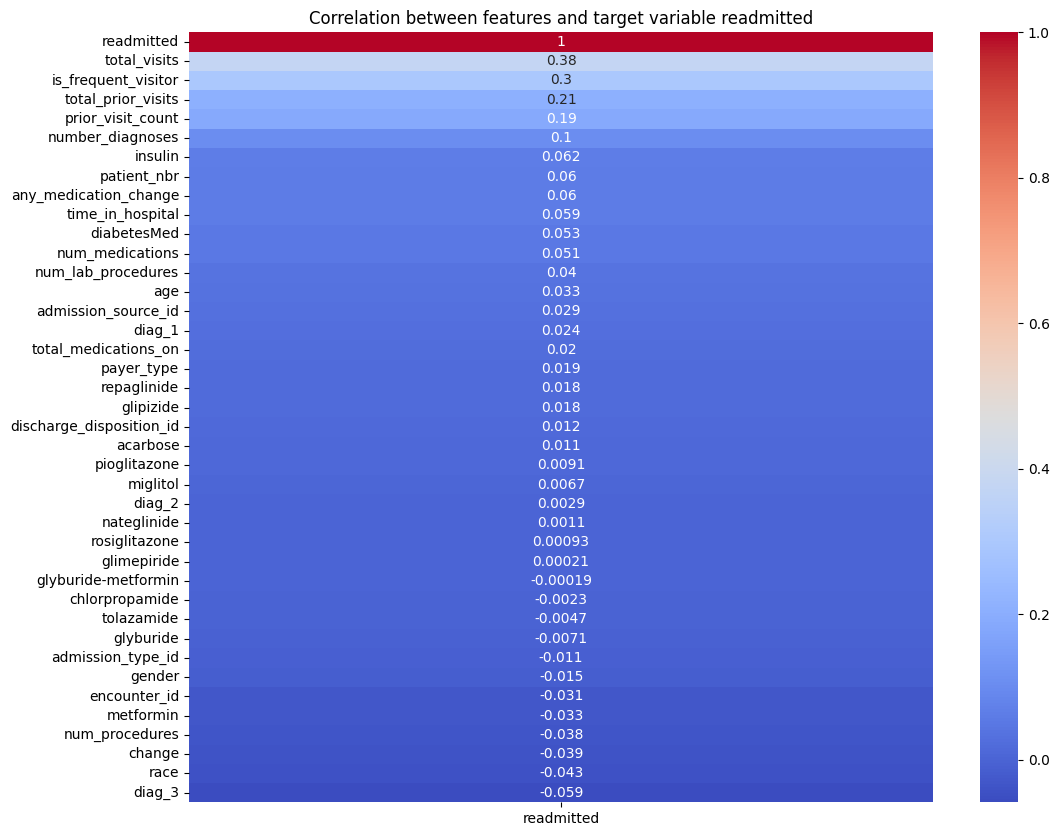

In [166]:
#see correlation between features and target variable readmitted using heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df_final.corr()['readmitted'].sort_values(ascending=False).to_frame(), annot=True, cmap='coolwarm')
plt.title('Correlation between features and target variable readmitted')
plt.show()

In [167]:
#drop low correlated features with readmitted (correlation less than 0.05)
low_correlation_features = df_final.corr()['readmitted'][df_final.corr()['readmitted'].abs() < 0.005].index
df_final.drop(low_correlation_features, axis=1, inplace=True)

In [168]:
df_final

,encounter_id,patient_nbr,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,diabetesMed,readmitted,payer_type,race,total_prior_visits,total_medications_on,any_medication_change,prior_visit_count,total_visits,is_frequent_visitor
34503,12522,48330783,0,8,2,1,4,13,68,2,...,1,0,0,0,0,2,0,0,1,0
33451,15738,63555939,0,9,3,3,4,12,33,3,...,1,0,0,0,0,2,0,0,1,0
27448,16680,42519267,1,4,1,1,7,1,51,0,...,1,0,0,0,0,2,0,0,1,0
13320,28236,89869032,0,4,1,1,7,9,47,2,...,1,1,0,1,0,1,0,0,1,0
11978,35754,82637451,1,5,2,1,2,3,31,6,...,1,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44436,443847176,50375628,0,6,1,1,7,6,45,1,...,1,1,1,1,6,2,1,3,4,1
68010,443847548,100162476,1,7,1,3,7,3,51,0,...,1,1,4,1,0,2,1,1,2,0
52643,443847782,74694222,0,8,1,4,5,5,33,3,...,1,0,4,1,1,1,0,1,2,0
21157,443857166,31693671,0,8,2,3,7,10,45,2,...,1,0,4,0,1,3,1,2,3,0


In [36]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 4.4 MB/s eta 0:00:00m eta 0:00:010:00:01


In [169]:
X = df_final.drop('readmitted', axis=1)
y = df_final['readmitted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [170]:
## try LightGBM
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028801 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1285
[LightGBM] [Info] Number of data points in the train set: 56988, number of used features: 32
[LightGBM] [Info] Start training from score -0.614158
[LightGBM] [Info] Start training from score -1.057462
[LightGBM] [Info] Start training from score -2.193127
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.96      0.83      7569
           1       0.70      0.58      0.63      5087
           2       0.57      0.05      0.10      1592

    accuracy                           0.72     14248
   macro avg       0.67      0.53      0.52     14248
weighted avg       0.70      0.72      0.68     14248

Confusion Matrix:
 [[7243  320    6]
 [2093 2937   57]
 [ 544  963   85]]
Accura

In [171]:
#print all f1 scores micro, macro, weighted
print("F1 Score (Micro):", f1_score(y_test, y_pred, average='micro'))
print("F1 Score (Macro):", f1_score(y_test, y_pred, average='macro'))
print("F1 Score (Weighted):", f1_score(y_test, y_pred, average='weighted'))

F1 Score (Micro): 0.7204519932622122
F1 Score (Macro): 0.5196766148453654
F1 Score (Weighted): 0.6772777211864827


In [172]:
#print percision, recall, f1 score for each class
print("Precision, Recall, F1 Score for each class:\n", classification_report(y_test, y_pred))

Precision, Recall, F1 Score for each class:
               precision    recall  f1-score   support

           0       0.73      0.96      0.83      7569
           1       0.70      0.58      0.63      5087
           2       0.57      0.05      0.10      1592

    accuracy                           0.72     14248
   macro avg       0.67      0.53      0.52     14248
weighted avg       0.70      0.72      0.68     14248



In [174]:
#low_correlation_features
low_correlation_features= df_final.corr()['readmitted'][df_final.corr()['readmitted'].abs() < 0.005].index

### Try Test set

In [176]:
import pandas as pd
from encoding_Script import encode_features
from Feature_Enginerring import engineer_features

# 1. Load the raw test data
df_test = pd.read_csv('test.csv')

# 2. Apply the exact same cleaning steps you did on train data
df_test_clean = df_test.drop(['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult'], axis=1, errors='ignore')
if 'payer_code' in df_test_clean.columns:
    df_test_clean['payer_code'] = df_test_clean['payer_code'].replace('?', 'Unknown')

# 3. Apply your encoding and feature engineering scripts
df_test_encoded = encode_features(df_test_clean)
df_test_final = engineer_features(df_test_encoded)

# 4. Bring back patient_nbr and encounter_id temporarily
df_test_final["encounter_id"] = df_test["encounter_id"].astype(int)
df_test_final["patient_nbr"] = df_test["patient_nbr"]

# SORT the dataset for cumulative counts
df_test_final.sort_values(by=['encounter_id', 'patient_nbr'], inplace=True)

# Recreate engineered grouped features
df_test_final["prior_visit_count"] = df_test_final.groupby('patient_nbr').cumcount()
df_test_final["total_visits"] = df_test_final.groupby('patient_nbr')['encounter_id'].transform('count')
df_test_final["is_frequent_visitor"] = (df_test_final["total_visits"] > 3).astype(int)

# >>> THE FIX: Save the correctly SORTED encounter_ids! <<<
sorted_encounter_ids = df_test_final['encounter_id'].copy()

# Now drop identifiers since model doesn't need them
df_test_final.drop(columns=['patient_nbr', 'encounter_id'], inplace=True)

# 5. Drop low-correlation columns if you calculated them earlier
df_test_final.drop(columns=low_correlation_features, errors='ignore', inplace=True)

# Align columns exactly to X_train
df_test_final = df_test_final.reindex(columns=X_train.columns, fill_value=0)

# 6. Make Predictions
test_predictions = lgbm.predict(df_test_final)

# 7. Convert numerical predictions (0, 1, 2) back to str labels
label_mapping = {0: 'NO', 1: '>30', 2: '<30'}
mapped_predictions = [label_mapping[pred] for pred in test_predictions]

# 8. Create Submission using the SORTED encounter_ids!
submission = pd.DataFrame({
    'encounter_id': sorted_encounter_ids,
    'readmitted': mapped_predictions
})

# 9. Save to a new CSV file
submission.to_csv('my_fixed_submission.csv', index=False)

print("Predictions successfully translated and saved to 'my_fixed_submission.csv'!")

Predictions successfully translated and saved to 'my_fixed_submission.csv'!


In [177]:
import pandas as pd
from encoding_Script import encode_features
from Feature_Enginerring import engineer_features
from lightgbm import LGBMClassifier

print("1. Loading raw data...")
df_train_raw = pd.read_csv('train.csv')
df_test_raw = pd.read_csv('test.csv')

# Save original target mappings to join back later (resilient against sorting)
target_df = df_train_raw[['encounter_id', 'readmitted']].copy()
target_map = {"NO": 0, ">30": 1, "<30": 2}
target_df['readmitted_num'] = target_df['readmitted'].map(target_map)

# Add markers and combine
df_train_raw['is_test'] = 0
df_test_raw['is_test'] = 1
df_train_raw = df_train_raw.drop(columns=['readmitted']) # Drop from train temporarily

combined = pd.concat([df_train_raw, df_test_raw], axis=0, ignore_index=True)

print("2. Applying cleaning and custom scripts to combined dataset...")
# Clean
combined.drop(['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult'], axis=1, errors='ignore', inplace=True)
if 'payer_code' in combined.columns:
    combined['payer_code'] = combined['payer_code'].replace('?', 'Unknown')

# Custom scripts (Applied AT THE SAME TIME guarantees identical features!)
combined_encoded = encode_features(combined)
combined_final = engineer_features(combined_encoded)

print("3. Doing grouped Patient feature engineering...")
combined_final["encounter_id"] = combined["encounter_id"].astype(int)
combined_final["patient_nbr"] = combined["patient_nbr"]
combined_final["is_test"] = combined["is_test"]

# Sort is necessary for temporal grouping
combined_final.sort_values(by=['patient_nbr', 'encounter_id'], inplace=True)

combined_final["prior_visit_count"] = combined_final.groupby('patient_nbr').cumcount()
combined_final["total_visits"] = combined_final.groupby('patient_nbr')['encounter_id'].transform('count')
combined_final["is_frequent_visitor"] = (combined_final["total_visits"] > 3).astype(int)

print("4. Splitting Train and Test back apart...")
train_final = combined_final[combined_final['is_test'] == 0].copy()
test_final = combined_final[combined_final['is_test'] == 1].copy()

# Store exact Encounter IDs for the test submission
sorted_test_ids = test_final['encounter_id'].copy()

# Merge the target variable back onto the training set using encounter_id
train_final = train_final.merge(target_df[['encounter_id', 'readmitted_num']], on='encounter_id', how='left')

# Separate Features (X) and Target (y)
y_train = train_final['readmitted_num']
X_train = train_final.drop(columns=['patient_nbr', 'encounter_id', 'is_test', 'readmitted_num'])

X_test = test_final.drop(columns=['patient_nbr', 'encounter_id', 'is_test'])

# Ensure columns align perfectly
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("5. Training final model on properly aligned data...")
final_lgbm = LGBMClassifier(random_state=42)
final_lgbm.fit(X_train, y_train)

print("6. Predicting & Saving...")
test_predictions = final_lgbm.predict(X_test)

reverse_map = {0: 'NO', 1: '>30', 2: '<30'}
submission = pd.DataFrame({
    'encounter_id': sorted_test_ids,
    'readmitted': [reverse_map[pred] for pred in test_predictions]
})

submission.to_csv('my_bulletproof_submission.csv', index=False)
print("Done! Submitted file 'my_bulletproof_submission.csv' generated successfully.")
submission.head()

1. Loading raw data...
2. Applying cleaning and custom scripts to combined dataset...
3. Doing grouped Patient feature engineering...
4. Splitting Train and Test back apart...
5. Training final model on properly aligned data...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038999 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1064
[LightGBM] [Info] Number of data points in the train set: 71236, number of used features: 37
[LightGBM] [Info] Start training from score -0.617811
[LightGBM] [Info] Start training from score -1.051894
[LightGBM] [Info] Start training from score -2.192826
6. Predicting & Saving...
Done! Submitted file 'my_bulletproof_submission.csv' generated successfully.


,encounter_id,readmitted
92871,29758806,NO
85044,30180318,>30
78542,70190028,>30
96016,60892254,NO
97166,42812376,NO
